In [2]:
import sys, os
from pathlib import Path

# Find the repo root (the folder containing pyproject.toml) and make it the
# working directory + import path. This lets the notebook live in jupyter-notebooks/ while
# `import utils`, `import plotting`, `from models import model` and relative
# paths like "data/..." keep working as if run from the repo root.
_p = Path.cwd()
while not (_p / "pyproject.toml").exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
if str(_p) not in sys.path:
    sys.path.insert(0, str(_p))

In [3]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2


import plotting as pl
from models import model as md
import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import pickle
import os
import re
import json
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import kstest, shapiro, normaltest, zscore
import statsmodels.api as sm
import matplotlib.patches as mpatches
import pingouin as pg
from PIL import Image

from functools import reduce, partial

In [5]:
l_data_subset = ["testcase"]#["full_evaluate_actual", "full_evaluate_shuffled"]
l_rnd_seed = [1]
l_lr = [0.0005]
l_lmbda = [1e-07]
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
modeltype = "free_weights_no_scaling"
l_embed_dim = [2, 7, 15, 25, 35]

l_models_embedding_only = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_embed_dim=l_embed_dim,
    modelversion=modelversion, l_lmbda=l_lmbda, modeltype=modeltype, l_id_weights_type=l_id_weights
)[0]

In [6]:
l_df_train_eval_id_embedding = ut.model_detail_dict(l_models_embedding_only, True)

In [7]:
df_train_eval_id_embedding = reduce(lambda x, y: pd.concat([x, y], axis=0, ignore_index=True), l_df_train_eval_id_embedding)
df_train_eval_id_embedding["epoch"] = df_train_eval_id_embedding.groupby(
    ["modeltype", "data_subset", "ndim", "lambda"]
).cumcount()

In [8]:
df_train_eval_long_id_embedding = pd.melt(
    df_train_eval_id_embedding, 
    id_vars=["modeltype", "data_subset", "ndim", "lambda", "epoch"], 
    value_vars = ["train_acc_max", "test_acc_max", "train_acc_proba", "test_acc_proba", "train_losses", "test_losses"], 
    var_name = "Variable",
    value_name = "Accuracy"
)

In [9]:
df_train_eval_long_id_embedding['lambda_ndim'] = df_train_eval_long_id_embedding['lambda'].astype(str) + '_' + df_train_eval_long_id_embedding['ndim'].astype(str)
df_train_eval_long_id_embedding['modeltype_lh'] = df_train_eval_long_id_embedding['modeltype'].astype(str)

In [10]:
df_train_eval_long_id_embedding.rename(columns = {"modeltype":"md", "lambda":"l"}, inplace=True)

## only embedding models

In [11]:
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["data_subset"] == "full_evaluate_actual", "data_subset"] = "Actual"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["data_subset"] == "full_evaluate_shuffled", "data_subset"] = "Shuffled"

df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "test_acc_max", "Variable"] = "ArgMax"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "test_acc_proba", "Variable"] = "SoftMax"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "train_acc_max", "Variable"] = "ArgMax Train"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "train_acc_proba", "Variable"] = "SoftMax Train"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "train_losses", "Variable"] = "Train Loss"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "test_losses", "Variable"] = "Test Loss"

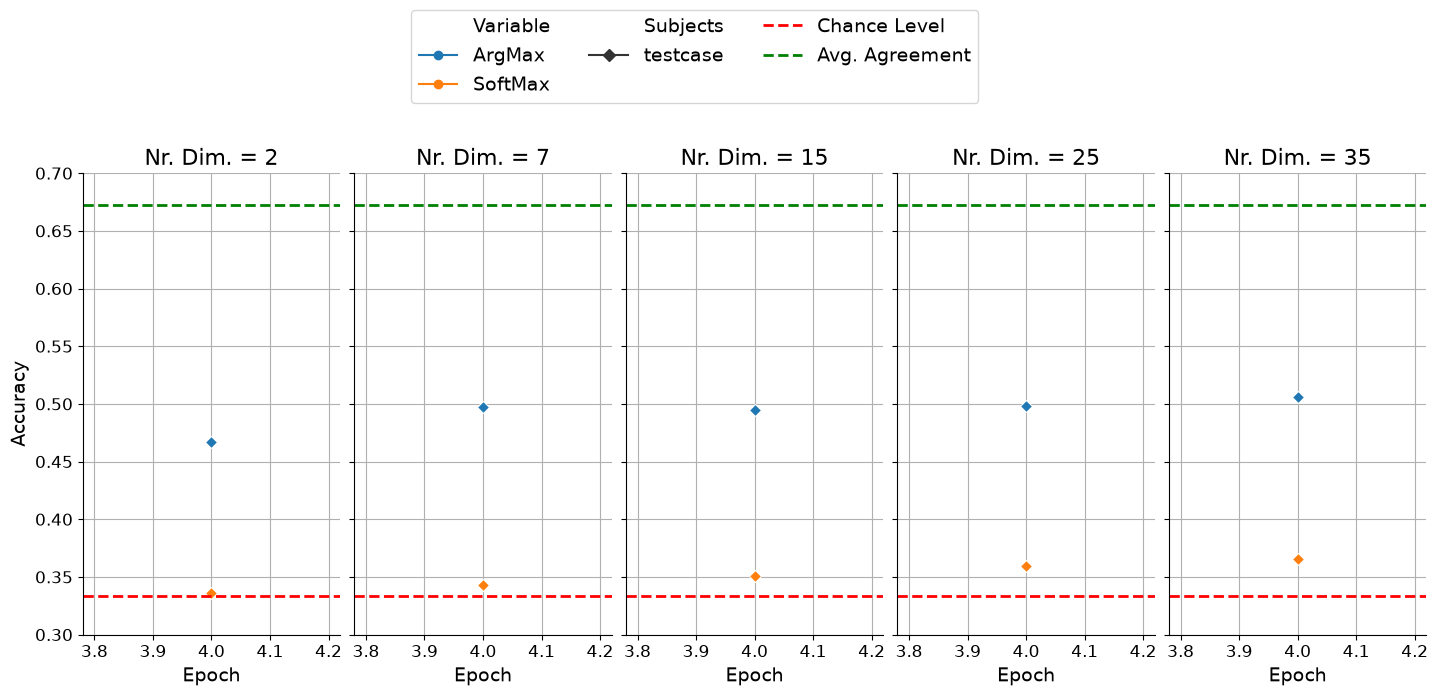

In [13]:
substring1 = "Train"
substring2 = "Max"
marker_styles = {
    "Actual": "o",  # circle
    "Shuffled": "s",  # square
    "testcase": "D",  # diamond
}
df_plt = df_train_eval_long_id_embedding.rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    ).query(
    (
        "(Epoch + 1) % 5 == 0 & "
        "md == 'free_weights_no_scaling' & "
        "Variable.str.contains(@substring2) & "
        "~Variable.str.contains(@substring1)"
    ), engine="python", 
)
# Create the FacetGrid without specifying an external axis
g = sns.relplot(
    data=df_plt, 
    x='Epoch', y='Accuracy', style = "Subjects", col="Nr. Dim.", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles
)
g._legend.remove()

# Add horizontal line and collect handles/labels
handles = []
labels = []
for ax in g.axes.flat:
    ax.grid(True)
    line = ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    line = ax.axhline(y=.6722, color='green', linestyle='--', linewidth=2, label='Avg. Agreement')

    ax.set_ylim(.3, .7)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Use a dictionary to remove duplicates while keeping order
legend_dict = dict(zip(labels, handles))
# Set global font size (affects most elements)
plt.rcParams.update({'font.size': 14})  # You can increase this to 16, 18, etc.

# Manually update each axis in the FacetGrid
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

# Update legend font size
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.45, 1.015),
    ncol=3,
    frameon=True,
    fontsize=14  # Add this line to scale legend text
)

g.fig.set_size_inches(15, 6)

In [14]:
import pickle

In [15]:
df_plt.to_csv("data/dataframes-plotting-ms/accuracy-over-ndim.csv")
with open("data/dataframes-plotting-ms/accuracy-over-ndim-legend.pkl", "wb") as f:
    pickle.dump(legend_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

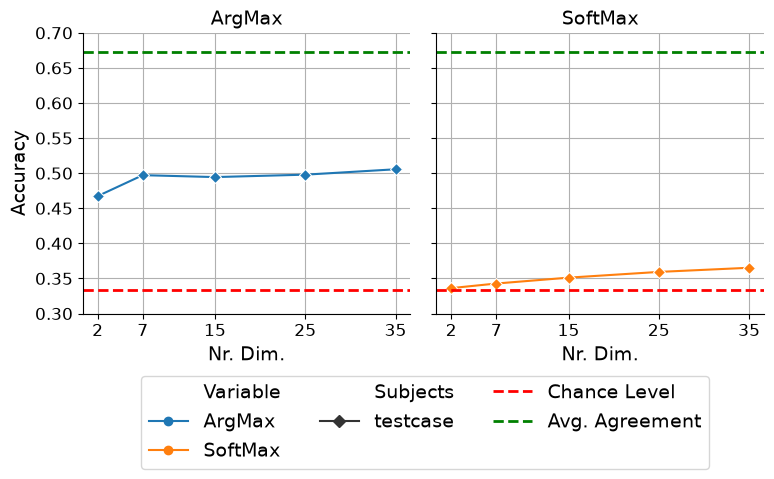

In [16]:
handles = []
labels = []
df_plt2 = df_plt.groupby(["md", "Subjects", "Nr. Dim.", "Variable"])["Accuracy"].max().reset_index()

g = sns.relplot(
    data=df_plt2, 
    x='Nr. Dim.', y='Accuracy', style = "Subjects", col="Variable", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles, legend=False
)

for ax in g.axes.flat:
    ax.grid(True)
    line = ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    line = ax.axhline(y=.6722, color='green', linestyle='--', linewidth=2, label='Avg. Agreement')
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xticks([2, 7, 15, 25, 35])
    ax.set_xticklabels([2, 7, 15, 25, 35])
    ax.set_ylim(.3, .7)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Update legend font size
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.55, -.225),
    ncol=3,
    frameon=True,
    fontsize=14  # Add this line to scale legend text
)
_ = g.set_titles("{col_name}")

In [17]:
substring2 = "Train"
df_embedding_best = df_train_eval_long_id_embedding.query(
    "~Variable.str.contains(@substring2)", engine="python"
).groupby(
    ["md", "data_subset", "ndim", "Variable"]
)["Accuracy"].max().reset_index()
df_embedding_best = df_embedding_best.pivot(
    index=["md", "data_subset", "ndim"], 
    columns=["Variable"], values="Accuracy"
).reset_index()
df_embedding_best_modeltype = df_embedding_best.pivot(
    index=["data_subset", "ndim"], 
    columns="md", values=["ArgMax", "SoftMax"]
).reset_index()
# Assume df_pivot has MultiIndex columns after pivot
df_embedding_best_modeltype.columns = [
    '_'.join(col).rstrip('_') if isinstance(col, tuple) else str(col).rstrip('_') for col in df_embedding_best_modeltype.columns
]

df_embedding_best_modeltype.sort_values("ArgMax_free_weights_no_scaling", ascending=False).head()

,data_subset,ndim,ArgMax_free_weights_no_scaling,SoftMax_free_weights_no_scaling
4,testcase,35,0.505579,0.365244
3,testcase,25,0.497893,0.359333
1,testcase,7,0.497603,0.342795
2,testcase,15,0.494463,0.351163
0,testcase,2,0.467851,0.336237
